# EdgeRunner | EDA 03: contrato de target y mapa de features

**Preguntas de esta exploracion**

1. Que significa exactamente el target ya materializado en `predictor_labels`?
2. Es suficiente para medir edge economicamente operable?
3. Que bloques de features podemos sintetizar desde SQLite antes de pensar en modelos complejos?

Este cuaderno no reconstruye el corpus ni entrena un predictor. Audita labels y ordena el espacio de features.

## Hallazgo previo de implementacion

El target de la DB no es una etiqueta de resolucion del evento ni una direccion de BTC spot. Es el movimiento futuro del **precio del token de Polymarket**.

Su generador real vive en el augmentador de datasets del recolector (no publicado):

- agrupa por `token_id` y ordena por `time_index_ns`;
- usa cuatro frames futuros del grid de `2 s`: horizonte `8 s`;
- calcula retorno relativo de `polymarket_mid`;
- etiqueta `up/flat/down` con umbral `5 bps`;
- genera una variante economica restando `half_spread + 2 bps`;
- calcula barrier hits durante el mismo path futuro.

La documentación histórica de *labeling* del recolector planteaba otra politica futura: delta absoluto, horizontes `5/15/60 s` y cost-aware fuera del core. Por eso los labels actuales se tratan aqui como **benchmark disponible**, no como definicion final aprobada para EdgeRunner.

In [1]:
from pathlib import Path
import sqlite3
import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

DB_PATH = Path(__import__("os").environ.get("EDGERUNNER_DB", "data/polymarket_week.sqlite3"))  # SQLite del recolector (no publicada: tamano/privacidad)
con = sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro&immutable=1", uri=True)
con.execute('PRAGMA query_only = ON')
FILTER_SQL = """
s.dataset_tier = 'core'
AND t.coverage_ratio >= 0.97
AND t.quality_score >= 70
AND t.core_gap_severe_segment_count = 0
""".strip()
SAMPLE_SQL = '(s.id % 100) = 0'
QUERY_LOG = []

def query(name, sql):
    start = time.perf_counter()
    out = pd.read_sql_query(sql, con)
    QUERY_LOG.append({'consulta': name, 'segundos': time.perf_counter() - start, 'rows': len(out)})
    return out

def classify(values, thresholds):
    return np.where(values >= thresholds, 'up', np.where(values <= -thresholds, 'down', 'flat'))

print('SQLite read-only:', DB_PATH)
print('query_only:', con.execute('PRAGMA query_only').fetchone()[0])

SQLite read-only: D:\polymarket_btc_probe_official_v1\polymarket_week.sqlite3
query_only: 1


## 1. Reproducir el target existente

Se utiliza la misma muestra diagnostica determinista del EDA anterior (`session_id % 100 = 0` dentro del baseline `core`). Es suficiente para auditar formulas y comparar definiciones; no es una seleccion de entrenamiento.

In [2]:
labels = query('muestra target con metadata', f"""
SELECT
  l.id, l.session_id, l.temporality, l.time_index_utc,
  l.current_mid, l.future_mid, l.future_return_bps,
  l.spread_bps_current, l.economic_cost_bps, l.economic_target_bps,
  l.economic_net_return_bps, l.neutral_threshold_bps, l.execution_buffer_bps,
  l.label_name, l.economic_label_name, l.target_up_hit, l.target_down_hit,
  l.first_target_hit_side, l.prediction_horizon_steps, l.prediction_horizon_seconds,
  m.tick_size, m.fees_enabled, m.fee_rate_bps
FROM predictor_labels l
JOIN collection_sessions s ON s.id = l.session_id
JOIN collection_session_telemetry t ON t.session_id = s.id
LEFT JOIN market_metadata m
  ON m.session_id = l.session_id AND m.market_id = l.market_id
WHERE {FILTER_SQL} AND {SAMPLE_SQL}
""")

labels['calc_relative_return_bps'] = ((labels['future_mid'] - labels['current_mid']) / labels['current_mid']) * 10000
labels['prob_delta_bp'] = (labels['future_mid'] - labels['current_mid']) * 10000
labels['calc_cost_bps'] = labels['spread_bps_current'].fillna(0).clip(lower=0) / 2 + labels['execution_buffer_bps'].clip(lower=0)
labels['calc_economic_net_bps'] = np.where(
    labels['future_return_bps'] > 0,
    labels['future_return_bps'] - labels['calc_cost_bps'],
    np.where(labels['future_return_bps'] < 0, labels['future_return_bps'] + labels['calc_cost_bps'], 0)
)
labels['calc_label_name'] = classify(labels['calc_relative_return_bps'], labels['neutral_threshold_bps'])
labels['calc_economic_label_name'] = classify(labels['calc_economic_net_bps'], labels['neutral_threshold_bps'])
labels['neutral_abs_price'] = labels['current_mid'] * labels['neutral_threshold_bps'] / 10000
labels['neutral_ticks'] = labels['neutral_abs_price'] / labels['tick_size']
labels['economic_target_ticks'] = (
    labels['current_mid'] * labels['economic_target_bps'] / 10000 / labels['tick_size']
)

policy = labels[[
    'prediction_horizon_steps', 'prediction_horizon_seconds', 'neutral_threshold_bps',
    'execution_buffer_bps', 'tick_size', 'fees_enabled', 'fee_rate_bps'
]].drop_duplicates()
label_mismatch = int((labels['label_name'] != labels['calc_label_name']).sum())
economic_mismatch = int((labels['economic_label_name'] != labels['calc_economic_label_name']).sum())

display(Markdown(f"""
**Muestra auditada:** `{len(labels):,}` filas.  
**Formula de `label_name`:** desacuerdos `{label_mismatch}`.  
**Formula economica recomputada desde columnas persistidas:** desacuerdos `{economic_mismatch}`.
"""))
display(policy.style.hide(axis='index'))


**Muestra auditada:** `24,288` filas.  
**Formula de `label_name`:** desacuerdos `0`.  
**Formula economica recomputada desde columnas persistidas:** desacuerdos `2`.


prediction_horizon_steps,prediction_horizon_seconds,neutral_threshold_bps,execution_buffer_bps,tick_size,fees_enabled,fee_rate_bps
4,8.000000,5.000000,2.000000,0.010000,1,700.000000


In [3]:
ambiguous = labels[labels['economic_label_name'] != labels['calc_economic_label_name']][[
    'id', 'session_id', 'time_index_utc', 'current_mid', 'future_mid', 'future_return_bps',
    'economic_cost_bps', 'economic_net_return_bps', 'economic_label_name', 'calc_economic_label_name'
]]
display(ambiguous.style.format({
    'current_mid': '{:.6f}', 'future_mid': '{:.6f}', 'future_return_bps': '{:.6f}',
    'economic_cost_bps': '{:.6f}', 'economic_net_return_bps': '{:.6f}'
}).hide(axis='index'))
display(Markdown(
    '**Interpretacion.** Los dos desacuerdos muestran `current_mid == future_mid` y '
    '`future_return_bps == 0`, mientras el label conserva un movimiento economico negativo. '
    'La implementacion local revisada no explica ese resultado para retorno cero: queda como '
    'anomalia de generacion/versionado pendiente de reproducir desde observaciones base. '
    'La nueva familia de labels no debe transformarse desde `predictor_labels`.'
))

id,session_id,time_index_utc,current_mid,future_mid,future_return_bps,economic_cost_bps,economic_net_return_bps,economic_label_name,calc_economic_label_name
652580,700,2026-05-15T06:40:21.762476Z,0.295000,0.295000,0.000000,171.491525,-171.491525,down,flat
652736,700,2026-05-15T06:40:21.762476Z,0.705000,0.705000,0.000000,72.921986,-72.921986,down,flat


**Interpretacion.** Los dos desacuerdos muestran `current_mid == future_mid` y `future_return_bps == 0`, mientras el label conserva un movimiento economico negativo. La implementacion local revisada no explica ese resultado para retorno cero: queda como anomalia de generacion/versionado pendiente de reproducir desde observaciones base. La nueva familia de labels no debe transformarse desde `predictor_labels`.

## 2. Dependencia entre tokens complementarios

Un mercado binario presenta dos tokens por instante. Aunque cada token sea una observacion valida, no son dos evidencias estadisticamente independientes si sus precios y movimientos son complementarios. Esta auditoria agrupa por `session_id + market_id + condition_id + time_index_ns`.

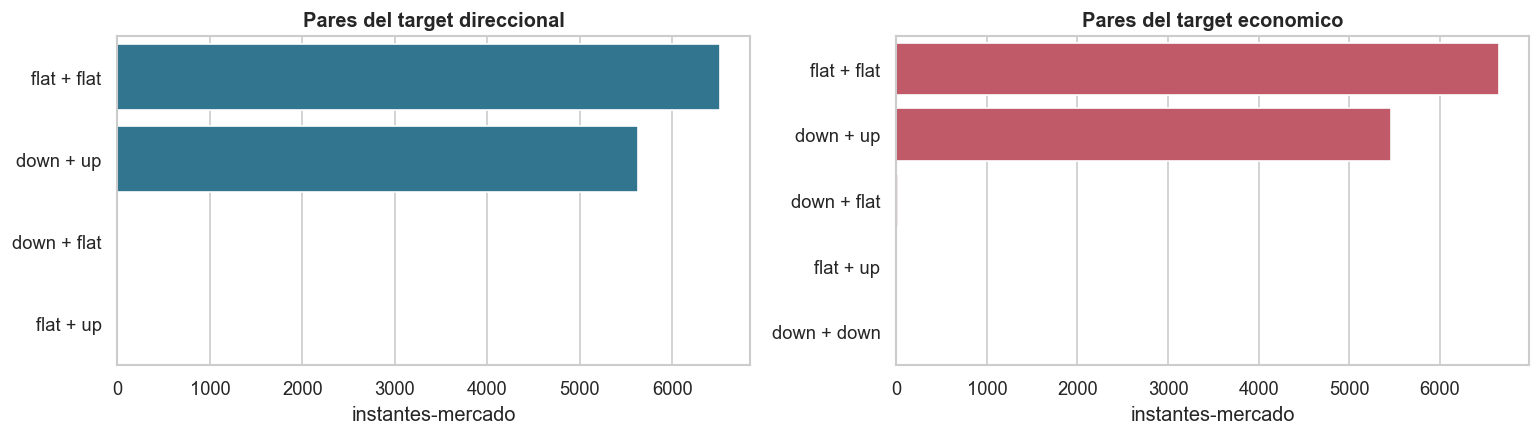

pair,market_frames
flat + flat,"6,514"
down + up,"5,628"
down + flat,1
flat + up,1


**Unidad efectiva.** `24,288` filas token corresponden a `12,144` instantes-mercado; todos contienen dos tokens. Las metricas futuras deben reportarse tambien por `market-frame` y los folds deben mantener cada `condition_id` unido.

In [4]:
paired_rows = query('dependencia tokens complementarios', f"""
SELECT
  l.session_id, l.market_id, l.condition_id, l.time_index_ns,
  l.label_name, l.economic_label_name, l.current_mid, l.future_mid
FROM predictor_labels l
JOIN collection_sessions s ON s.id = l.session_id
JOIN collection_session_telemetry t ON t.session_id = s.id
WHERE {FILTER_SQL} AND {SAMPLE_SQL}
""")
paired = paired_rows.groupby(['session_id', 'market_id', 'condition_id', 'time_index_ns']).agg(
    token_rows=('label_name', 'size'),
    direction_pair=('label_name', lambda values: ' + '.join(sorted(values))),
    economic_pair=('economic_label_name', lambda values: ' + '.join(sorted(values))),
    current_mid_sum=('current_mid', 'sum'),
    future_mid_sum=('future_mid', 'sum'),
).reset_index()
direction_pairs = paired['direction_pair'].value_counts().rename_axis('pair').reset_index(name='market_frames')
economic_pairs = paired['economic_pair'].value_counts().rename_axis('pair').reset_index(name='market_frames')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.barplot(data=direction_pairs, y='pair', x='market_frames', color='#227c9d', ax=axes[0])
axes[0].set(title='Pares del target direccional', xlabel='instantes-mercado', ylabel='')
sns.barplot(data=economic_pairs, y='pair', x='market_frames', color='#d1495b', ax=axes[1])
axes[1].set(title='Pares del target economico', xlabel='instantes-mercado', ylabel='')
plt.tight_layout()
plt.show()
display(direction_pairs.style.format({'market_frames': '{:,.0f}'}).hide(axis='index'))
display(Markdown(
    f"**Unidad efectiva.** `{len(paired_rows):,}` filas token corresponden a "
    f"`{len(paired):,}` instantes-mercado; todos contienen dos tokens. "
    "Las metricas futuras deben reportarse tambien por `market-frame` y los folds "
    "deben mantener cada `condition_id` unido."
))

## 3. Comparar definiciones de direccion

El label actual usa retorno relativo. Para el precio de un contrato binario interesa comparar dos alternativas mas interpretables:

- `abs_50bp`: delta absoluto de probabilidad con banda de `50 bp` (`0,005` dolares, medio tick si `tick_size=0,01`).
- `one_tick`: solo considera direccion si el movimiento alcanza al menos un tick.

No se elige aun un ganador: se comprueba cuanto cambia la poblacion etiquetada.

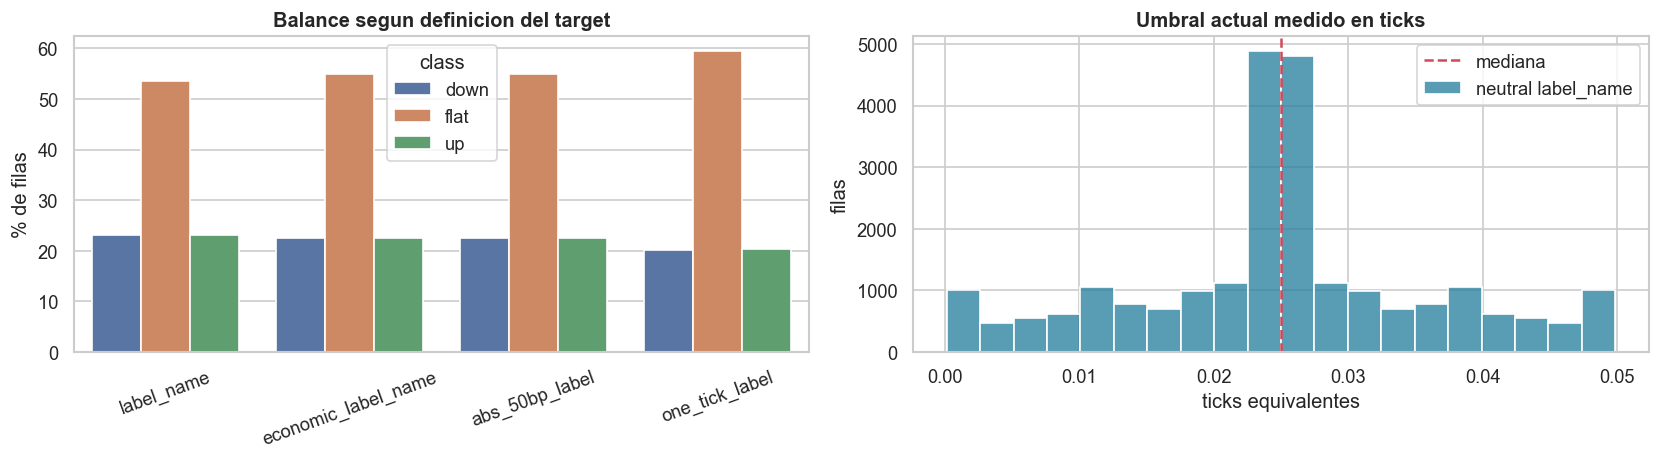

class,down,flat,up
target,,,
abs_50bp_label,22.57%,54.85%,22.58%
economic_label_name,22.58%,54.89%,22.53%
label_name,23.18%,53.65%,23.18%
one_tick_label,20.14%,59.44%,20.42%


,neutral_ticks,economic_target_ticks
count,24288.0000,24288.0000
mean,0.0250,0.5742
std,0.0113,0.3225
min,0.0002,0.0506
10%,0.0092,0.5123
50%,0.0250,0.5354
90%,0.0407,0.5634
95%,0.0468,1.0084
99%,0.0492,1.5402
max,0.0498,23.0434


In [5]:
labels['abs_50bp_label'] = classify(labels['prob_delta_bp'], 50.0)
labels['delta_ticks'] = (labels['future_mid'] - labels['current_mid']) / labels['tick_size']
labels['one_tick_label'] = classify(labels['delta_ticks'], 1.0)
comparison_rows = []
for name in ['label_name', 'economic_label_name', 'abs_50bp_label', 'one_tick_label']:
    counts = labels[name].value_counts().reindex(['down', 'flat', 'up'], fill_value=0)
    for cls, count in counts.items():
        comparison_rows.append({'target': name, 'class': cls, 'rows': count, 'pct': 100 * count / len(labels)})
comparison = pd.DataFrame(comparison_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=comparison, x='target', y='pct', hue='class', hue_order=['down', 'flat', 'up'], ax=axes[0])
axes[0].set(title='Balance segun definicion del target', xlabel='', ylabel='% de filas')
axes[0].tick_params(axis='x', rotation=20)
sns.histplot(labels['neutral_ticks'], bins=20, color='#227c9d', ax=axes[1], label='neutral label_name')
axes[1].axvline(labels['neutral_ticks'].median(), color='#d1495b', linestyle='--', label='mediana')
axes[1].set(title='Umbral actual medido en ticks', xlabel='ticks equivalentes', ylabel='filas')
axes[1].legend()
plt.tight_layout()
plt.show()
display(comparison.pivot(index='target', columns='class', values='pct').style.format('{:.2f}%'))
display(labels[['neutral_ticks', 'economic_target_ticks']].describe(percentiles=[.1, .5, .9, .95, .99]).style.format('{:.4f}'))

In [6]:
median_neutral_ticks = labels['neutral_ticks'].median()
median_economic_ticks = labels['economic_target_ticks'].median()
display(Markdown(f"""
**Decision de target.** El umbral direccional existente equivale a solo
`{median_neutral_ticks:.3f}` ticks en mediana; es un label de movimiento, no una prueba
de edge ejecutable. El target economico sube a `{median_economic_ticks:.3f}` ticks en
mediana, pero omite una modelizacion validada de fees, fill, slippage y salida.

Por tanto se conservara `predictor_labels` como benchmark y se propondra calcular offline,
desde observaciones SQLite, una familia `prob_delta_3c_H_v1` en delta absoluto/ticks y una
familia posterior `executable_markout_H_v1` con politica de coste explicita.
"""))


**Decision de target.** El umbral direccional existente equivale a solo
`0.025` ticks en mediana; es un label de movimiento, no una prueba
de edge ejecutable. El target economico sube a `0.535` ticks en
mediana, pero omite una modelizacion validada de fees, fill, slippage y salida.

Por tanto se conservara `predictor_labels` como benchmark y se propondra calcular offline,
desde observaciones SQLite, una familia `prob_delta_3c_H_v1` en delta absoluto/ticks y una
familia posterior `executable_markout_H_v1` con politica de coste explicita.


## 4. Familias de target que merece contrastar

Las etiquetas son resultados futuros y nunca forman parte del vector de entrada.

In [7]:
target_families = pd.DataFrame([
    ('existing_rel_return_8s_v1', 'Retorno relativo del mid; labels actuales', 'benchmark disponible', 'ya materializado'),
    ('prob_delta_3c_H_v1', 'Delta absoluto / tick normalizado; down-flat-up', 'primer target direccional', 'alta'),
    ('microprice_delta_H_v1', 'Delta microprice con mask de fuente', 'auxiliar microestructura', 'media'),
    ('path_barrier_prob_H_v1', 'Primer barrier hit en delta/ticks', 'oportunidad intrahorizonte', 'alta despues de direccional'),
    ('executable_markout_H_v1', 'Entrada observable + markout neto definido', 'edge economico', 'alta, necesita coste'),
    ('fill_then_markout_H_v1', 'Fill/slippage/adverse selection simulado', 'riesgo y ejecucion', 'posterior'),
], columns=['familia', 'definicion', 'uso', 'prioridad'])
display(target_families.style.hide(axis='index'))

familia,definicion,uso,prioridad
existing_rel_return_8s_v1,Retorno relativo del mid; labels actuales,benchmark disponible,ya materializado
prob_delta_3c_H_v1,Delta absoluto / tick normalizado; down-flat-up,primer target direccional,alta
microprice_delta_H_v1,Delta microprice con mask de fuente,auxiliar microestructura,media
path_barrier_prob_H_v1,Primer barrier hit en delta/ticks,oportunidad intrahorizonte,alta despues de direccional
executable_markout_H_v1,Entrada observable + markout neto definido,edge economico,"alta, necesita coste"
fill_then_markout_H_v1,Fill/slippage/adverse selection simulado,riesgo y ejecucion,posterior


## 5. Bloques de features sintetizables

Ordenamos el backlog por valor para el primer predictor y por riesgo de leakage. El inventario completo y granular queda en `docs/05_target_y_features.md`.

orden,bloque,ejemplos,contrato,prioridad
1,Microestructura Polymarket,"mid lags/delta, spread ticks, microprice gap, imbalance, stale prefix",v1 causal; promover grid nativo,alta
2,Contrato y reloj,"seconds_to_end, progress, temporality, outcome, tick, fees flag",v1 causal desde metadata,alta
3,Spot/perp/Chainlink core,"returns, gaps, vol, OI/basis/funding, staleness, z-scores",v1 causal/missing-aware,alta
4,Complemento e intertemporal,"sum-to-one, asimetria tokens, curve residual, slope",causal; parte ya materializada,media-alta
5,Calidad por frame,"ages, missing masks, rolling past-only readiness",v1 causal; telemetry final solo filtro,alta
6,Contexto nativo,"holders, OI nativo, activity, fills agregados, concentration",requiere auditoria as-of,media-alta
7,Coste y ejecutabilidad,"ask/bid estimado, fee, markout, barriers, fill proxy",principalmente labels/riesgo,alta tras target
8,Sidecars / holdout,"liquidations, depth, coinbase, deribit, hyperliquid",sin trainable rows hoy,fuera v1


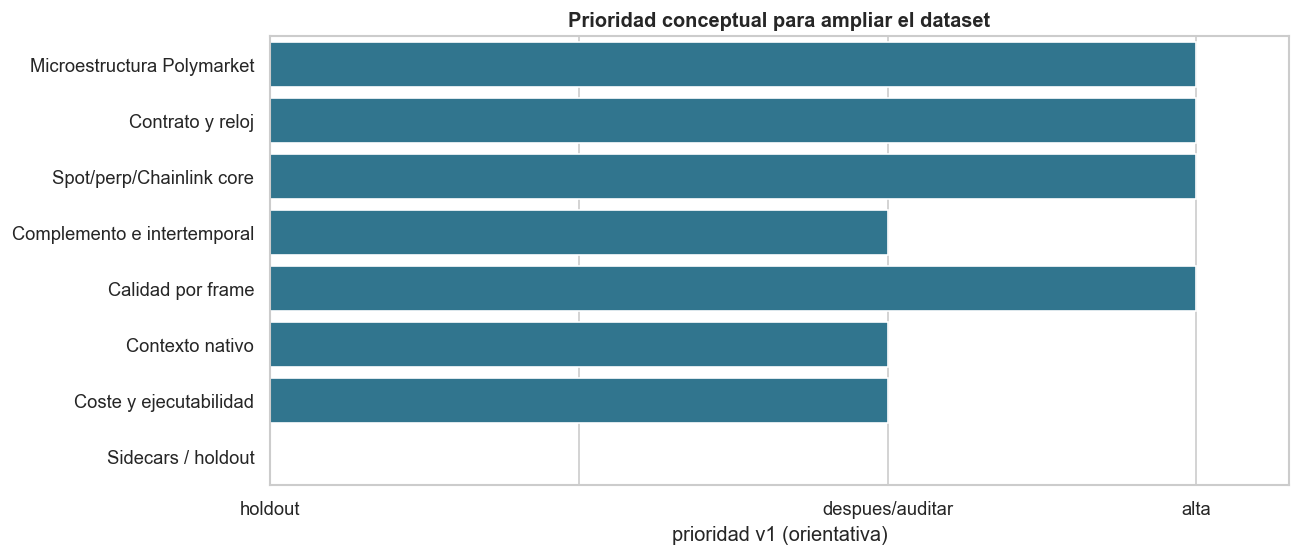

In [8]:
feature_blocks = pd.DataFrame([
    (1, 'Microestructura Polymarket', 'mid lags/delta, spread ticks, microprice gap, imbalance, stale prefix', 'v1 causal; promover grid nativo', 'alta'),
    (2, 'Contrato y reloj', 'seconds_to_end, progress, temporality, outcome, tick, fees flag', 'v1 causal desde metadata', 'alta'),
    (3, 'Spot/perp/Chainlink core', 'returns, gaps, vol, OI/basis/funding, staleness, z-scores', 'v1 causal/missing-aware', 'alta'),
    (4, 'Complemento e intertemporal', 'sum-to-one, asimetria tokens, curve residual, slope', 'causal; parte ya materializada', 'media-alta'),
    (5, 'Calidad por frame', 'ages, missing masks, rolling past-only readiness', 'v1 causal; telemetry final solo filtro', 'alta'),
    (6, 'Contexto nativo', 'holders, OI nativo, activity, fills agregados, concentration', 'requiere auditoria as-of', 'media-alta'),
    (7, 'Coste y ejecutabilidad', 'ask/bid estimado, fee, markout, barriers, fill proxy', 'principalmente labels/riesgo', 'alta tras target'),
    (8, 'Sidecars / holdout', 'liquidations, depth, coinbase, deribit, hyperliquid', 'sin trainable rows hoy', 'fuera v1'),
], columns=['orden', 'bloque', 'ejemplos', 'contrato', 'prioridad'])
display(feature_blocks.style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(11, 4.8))
priority_score = {'alta': 3, 'media-alta': 2, 'alta tras target': 2, 'fuera v1': 0}
plot = feature_blocks.copy()
plot['score'] = plot['prioridad'].map(priority_score)
sns.barplot(data=plot, y='bloque', x='score', color='#227c9d', ax=ax)
ax.set(title='Prioridad conceptual para ampliar el dataset', xlabel='prioridad v1 (orientativa)', ylabel='', xlim=(0, 3.3))
ax.set_xticks([0, 1, 2, 3], ['holdout', '', 'despues/auditar', 'alta'])
plt.tight_layout()
plt.show()

## 6. Guardarrail de leakage para ampliar features

| Material | Permitido como input en `t` | Tratamiento |
|---|---:|---|
| Valores y rolling calculados solo hasta `t` | Si | Feature candidata. |
| `market_metadata` conocido al seleccionar mercado | Si | Feature candidata con audit de timestamp. |
| Contexto holders/OI/activity de sesion | Aun no | Probar que es `as-of t` o usarlo solo para analisis. |
| `session_market_tradability` final | No | Filtro offline o reporte de segmento. |
| `collection_session_telemetry` final | No | Gate de calidad offline. |
| Toda columna de `predictor_labels` | No | Exclusivamente target/auditoria. |
| Sidecars sin disponibilidad entrenable | No | Mask/holdout; fuera v1. |

Particularmente importante: aunque `predictor_labels` contenga `current_mid`, `spread_bps_current` o flags de calidad, no deben entrar como features. Se obtienen de la capa de observacion causal para mantener separacion limpia entre input y target.

## 7. Orden de trabajo resultante

1. Mantener labels actuales como benchmark, no como verdad economica final.
2. En exploracion, medir labels alternativos en delta absoluto/ticks para `4/8/16 s` y, despues, `30/60 s` si la censura lo permite.
3. Promover en una vista exploratoria los campos Polymarket causales que faltan en la tabla columnar: spread, microprice, imbalance, stale y missing.
4. Auditar temporalidad `as-of` del contexto nativo.
5. Solo tras estas decisiones, proponer baselines por bloques con walk-forward purgado y test terminal sellado.

La siguiente fase sigue siendo explorar y decidir, no automatizar una extraccion definitiva.

In [9]:
display(Markdown('### Coste de consultas'))
display(pd.DataFrame(QUERY_LOG).sort_values('segundos', ascending=False).style.format({'segundos': '{:.3f}', 'rows': '{:,.0f}'}).hide(axis='index'))
con.close()

### Coste de consultas

consulta,segundos,rows
muestra target con metadata,3.089,"24,288"
dependencia tokens complementarios,0.098,"24,288"
